In [1]:
### IMPORTS ###

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [3]:
### HELPER ###

In [4]:
def decision(pvalue, alpha):
    if pvalue < alpha:
        print(f'reject H0: pvalue={pvalue} < {alpha}')
    else:
        print(f'fail to reject H0: pvalue={pvalue} >= {alpha}')

def standardize(X):
    return (X - X.mean()) / X.std()

In [5]:
### DATA CLEANING ###

In [6]:
# read in data
diseases = pd.read_csv("diseases.csv")

# first look at data
print(diseases.head())
print(diseases.columns)

# data types
diseases.dtypes

     Disease   County  Year     Sex  Cases  Population    Rate  Lower_95__CI  \
0  Amebiasis  Alameda  2001  Female    7.0      746596  0.938*         0.377   
1  Amebiasis  Alameda  2001    Male    9.0      718968  1.252*         0.572   
2  Amebiasis  Alameda  2001   Total   16.0     1465564  1.092*         0.624   
3  Amebiasis  Alameda  2002  Female    4.0      747987  0.535*         0.146   
4  Amebiasis  Alameda  2002    Male    5.0      720481  0.694*         0.225   

   Upper_95__CI  
0         1.932  
1         2.376  
2         1.773  
3         1.369  
4         1.620  
Index(['Disease', 'County', 'Year', 'Sex', 'Cases', 'Population', 'Rate',
       'Lower_95__CI', 'Upper_95__CI'],
      dtype='str')


Disease             str
County              str
Year              int64
Sex                 str
Cases           float64
Population        int64
Rate                str
Lower_95__CI    float64
Upper_95__CI    float64
dtype: object

In [7]:
# remove "Other" diseases
diseases = diseases[diseases["Disease"] != "Other"].copy()

# clean "Rate"
diseases["Rate"] = (diseases["Rate"].str.replace("*", "", regex=False))

# convert invalid strings to NaN
diseases["Rate"] = pd.to_numeric(diseases["Rate"], errors="coerce")

# OPTIONAL: if we only want county-level analysis, remove 'California' values
diseases = diseases[diseases["County"] != "California"].copy()

In [8]:
# missing values
print(diseases["Rate"].isna().sum())

129803


In [9]:
# a HUGE amount of rate values are missing, but we can calculate it ourselves and replace the column

# recompute rate
diseases["Rate"] = (diseases["Cases"] * 100000 / diseases["Population"])

In [10]:
# new missing values
print(diseases["Rate"].isna().sum())

4120


In [11]:
### EDA ###

In [12]:
# dataset overview

print("shape:", diseases.shape)

print("\ncolumns:")
print(diseases.columns)

print("\ndata types:")
print(diseases.dtypes)

print("\nmissing values:")
print(diseases.isnull().sum())

print("\nyears covered:")
print(diseases["Year"].min(), "-", diseases["Year"].max())

print("\nnumber of diseases:")
print(diseases["Disease"].nunique())

print("\nnumber of counties:")
print(diseases["County"].nunique())

print("\nsex categories:")
print(diseases["Sex"].unique())

shape: (161646, 9)

columns:
Index(['Disease', 'County', 'Year', 'Sex', 'Cases', 'Population', 'Rate',
       'Lower_95__CI', 'Upper_95__CI'],
      dtype='str')

data types:
Disease             str
County              str
Year              int64
Sex                 str
Cases           float64
Population        int64
Rate            float64
Lower_95__CI    float64
Upper_95__CI    float64
dtype: object

missing values:
Disease            0
County             0
Year               0
Sex                0
Cases           4120
Population         0
Rate            4120
Lower_95__CI    4966
Upper_95__CI    4966
dtype: int64

years covered:
2001 - 2019

number of diseases:
53

number of counties:
58

sex categories:
<StringArray>
['Female', 'Male', 'Total']
Length: 3, dtype: str


In [13]:
# summary statistics

print(diseases[["Cases", "Population", "Rate"]].describe())

               Cases    Population           Rate
count  157526.000000  1.616460e+05  157526.000000
mean        5.398829  4.313309e+05       1.038908
std        44.770313  1.018689e+06       6.446154
min         0.000000  5.630000e+02       0.000000
25%         0.000000  2.855900e+04       0.000000
50%         0.000000  1.139990e+05       0.000000
75%         0.000000  4.085990e+05       0.000000
max      3371.000000  1.026994e+07     405.723191


Disease
Campylobacteriosis                                  256781.0
Salmonellosis                                       181751.0
Coccidioidomycosis                                  146972.0
Giardiasis                                           82134.0
Shigellosis                                          72397.0
Shiga toxin-producing E. coli (STEC) without HUS     26872.0
Cryptosporidiosis                                    14171.0
Amebiasis                                            13582.0
Legionellosis                                         9469.0
Vibrio Infection (non-Cholera)                        6051.0
Malaria                                               4928.0
Yersiniosis                                           4604.0
Listeriosis                                           4173.0
Lyme Disease                                          3637.0
Typhoid Fever, case                                   2854.0
Name: Cases, dtype: float64


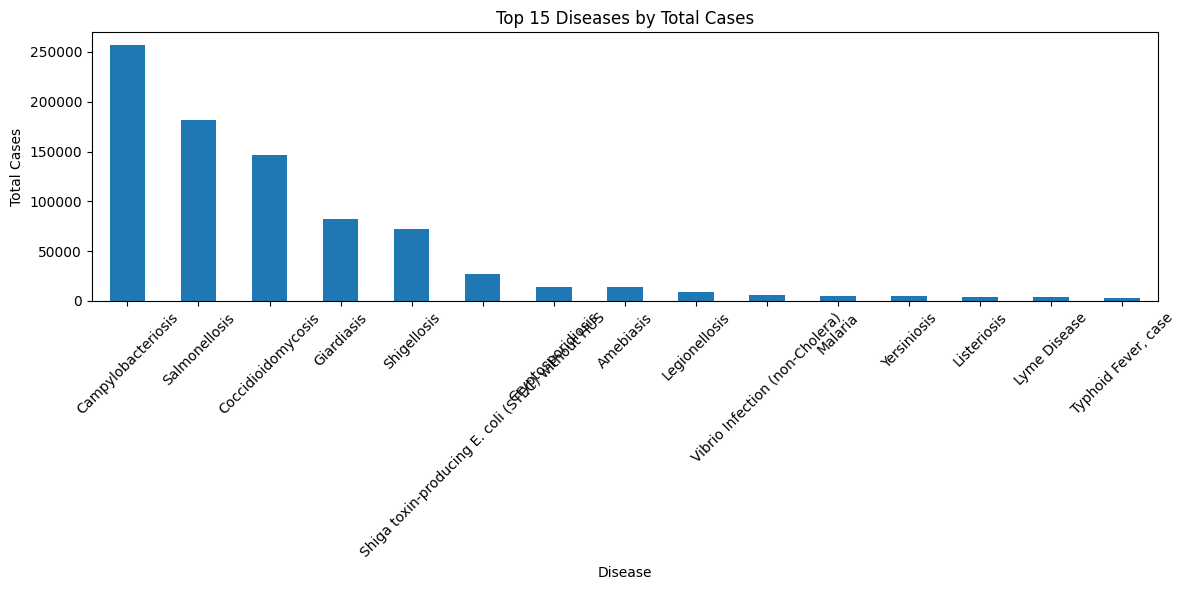

In [14]:
# total cases by disease
disease_totals = (diseases.groupby("Disease")["Cases"].sum().sort_values(ascending=False))

print(disease_totals.head(15))

# top diseases
top_diseases = disease_totals.head(15)

plt.figure(figsize=(12,6))

top_diseases.plot(kind="bar")

plt.title("Top 15 Diseases by Total Cases")
plt.ylabel("Total Cases")
plt.xlabel("Disease")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

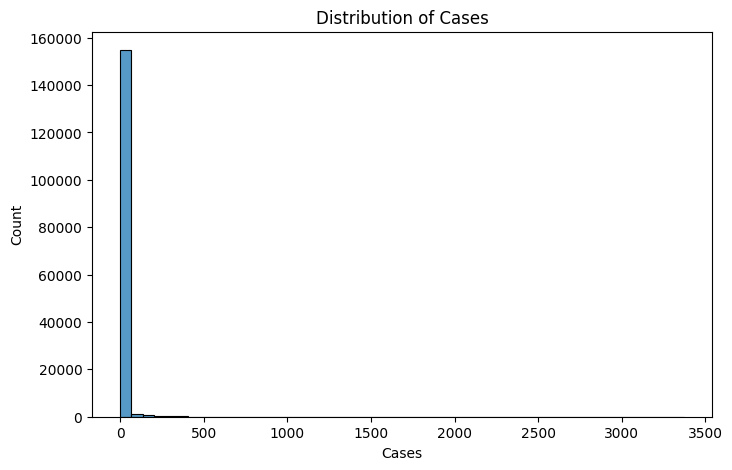

In [15]:
# distribution of cases

plt.figure(figsize=(8,5))

sns.histplot(diseases["Cases"], bins=50)

plt.title("Distribution of Cases")
plt.xlabel("Cases")

plt.show()

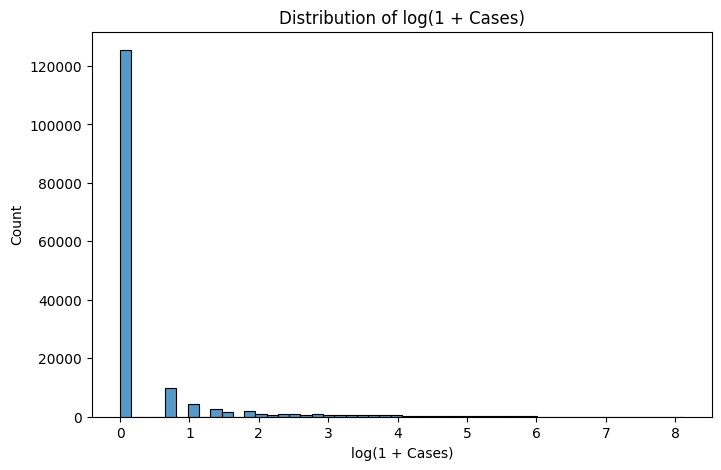

In [16]:
# log cases

plt.figure(figsize=(8,5))

sns.histplot(np.log1p(diseases["Cases"]),bins=50)

plt.title("Distribution of log(1 + Cases)")
plt.xlabel("log(1 + Cases)")

plt.show()

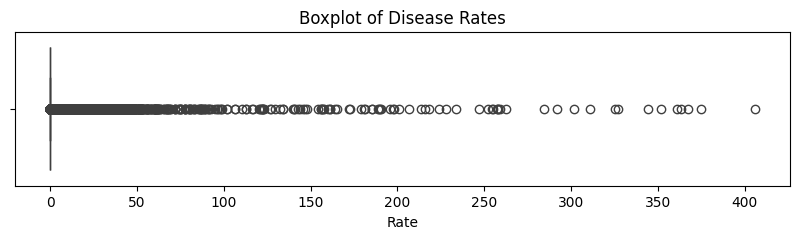

In [17]:
# distribution of rates
plt.figure(figsize=(10,2))

sns.boxplot(x=diseases["Rate"])

plt.title("Boxplot of Disease Rates")

plt.show()

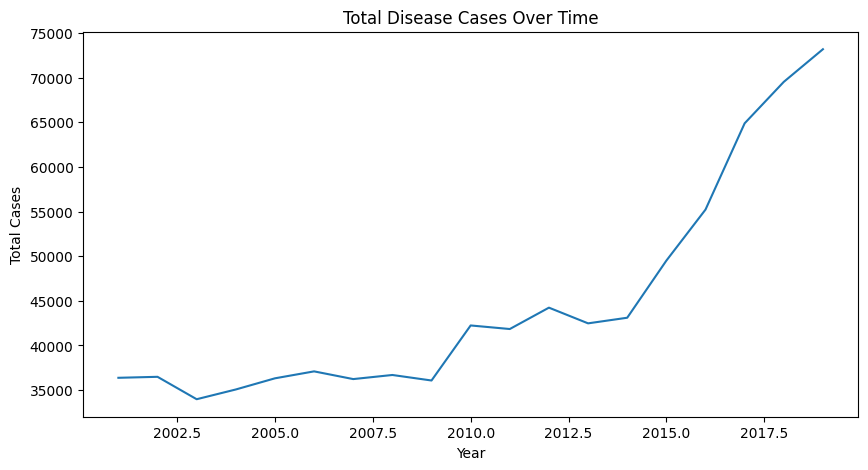

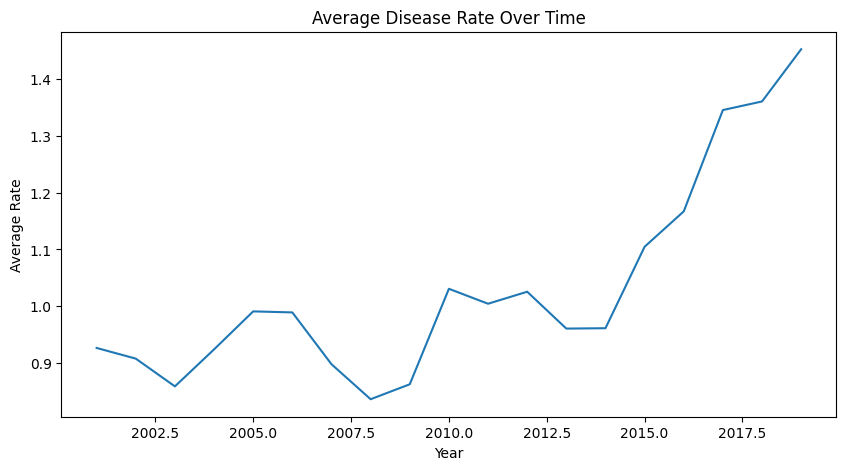

In [18]:
# trends over time
yearly_cases = (diseases.groupby("Year")["Cases"].sum())

plt.figure(figsize=(10,5))

plt.plot(yearly_cases.index,yearly_cases.values)

plt.title("Total Disease Cases Over Time")
plt.xlabel("Year")
plt.ylabel("Total Cases")

plt.show()

yearly_rates = (diseases.groupby("Year")["Rate"].mean())

plt.figure(figsize=(10,5))

plt.plot(yearly_rates.index,yearly_rates.values)

plt.title("Average Disease Rate Over Time")
plt.xlabel("Year")
plt.ylabel("Average Rate")

plt.show()

In [19]:
# county-level

county_rates = (diseases.groupby("County")["Rate"].mean().sort_values(ascending=False))

print(county_rates.head(15))

County
Kern               4.944694
Kings              2.923126
San Francisco      2.602451
Fresno             2.133497
San Luis Obispo    2.125976
Tulare             2.118383
Madera             1.766057
Marin              1.639496
San Mateo          1.599200
San Joaquin        1.536210
Merced             1.501804
Napa               1.455229
Imperial           1.441910
Stanislaus         1.438319
Alameda            1.389063
Name: Rate, dtype: float64


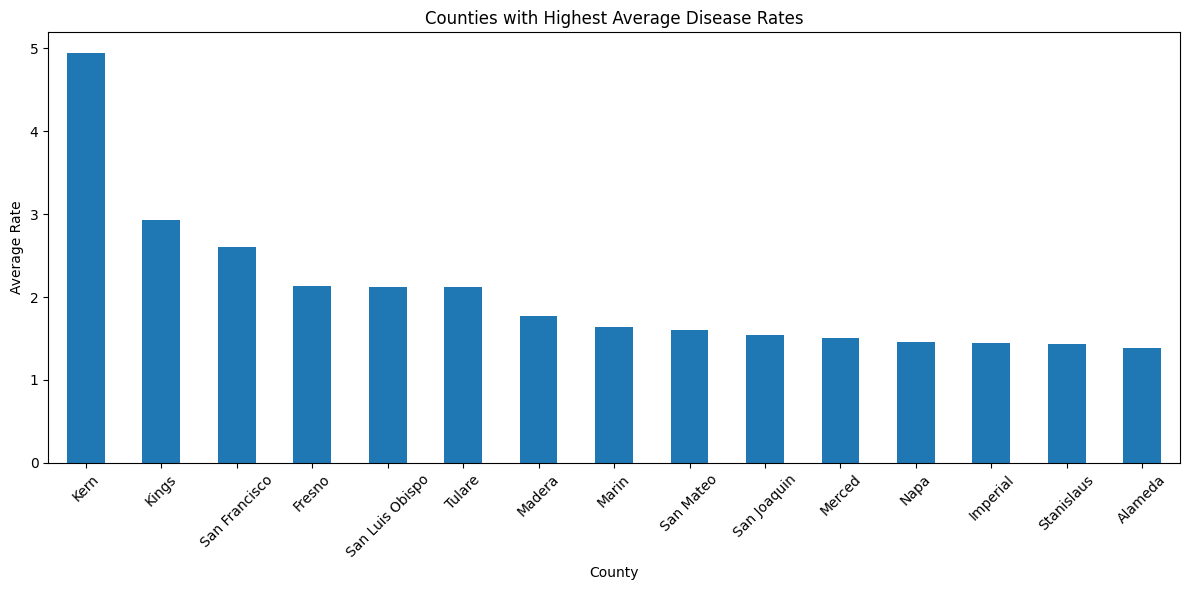

In [20]:
top_counties = county_rates.head(15)

plt.figure(figsize=(12,6))

top_counties.plot(kind="bar")

plt.title("Counties with Highest Average Disease Rates")
plt.xlabel("County")
plt.ylabel("Average Rate")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Sex
Female    0.816119
Male      1.043737
Total     1.248535
Name: Rate, dtype: float64


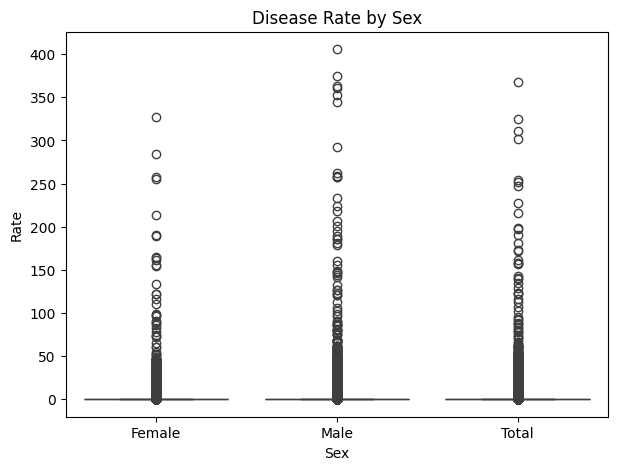

In [21]:
# by sex

sex_rates = (diseases.groupby("Sex")["Rate"].mean())

print(sex_rates)

plt.figure(figsize=(7,5))

sns.boxplot(data=diseases,x="Sex",y="Rate")

plt.title("Disease Rate by Sex")
plt.ylabel("Rate")

plt.show()

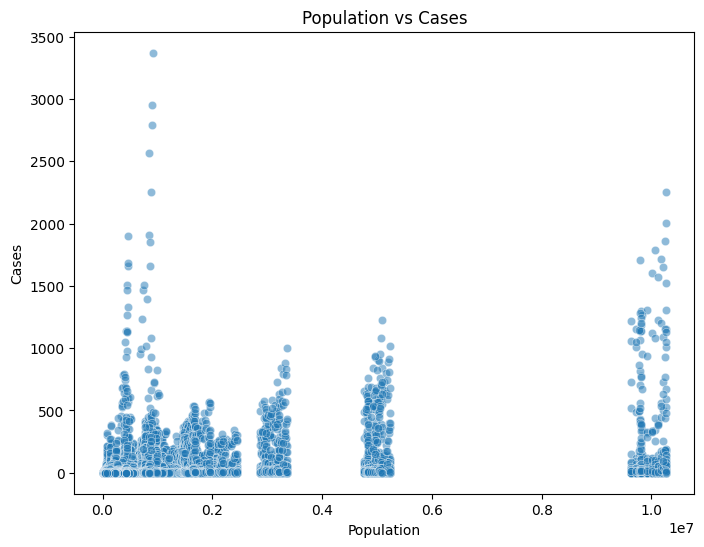

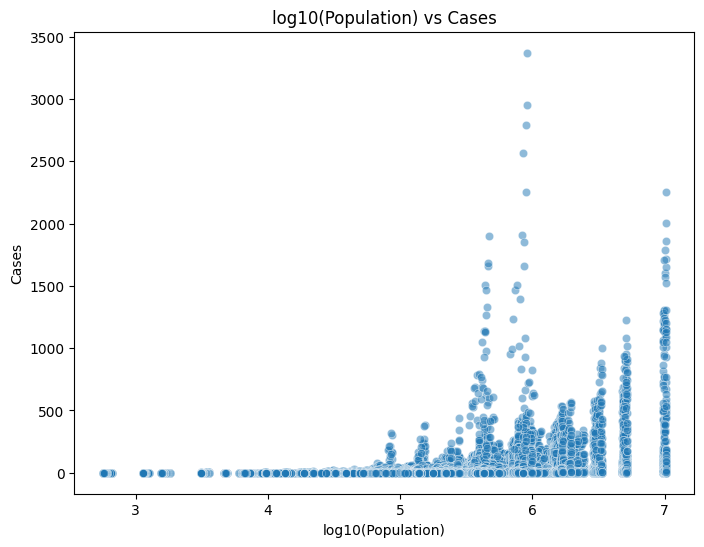

In [22]:
# by population

plt.figure(figsize=(8,6))

sns.scatterplot(data=diseases,x="Population",y="Cases",alpha=0.5)

plt.title("Population vs Cases")
plt.xlabel("Population")
plt.ylabel("Cases")

plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(x=np.log10(diseases["Population"]),y=diseases["Cases"],alpha=0.5)

plt.title("log10(Population) vs Cases")
plt.xlabel("log10(Population)")
plt.ylabel("Cases")

plt.show()

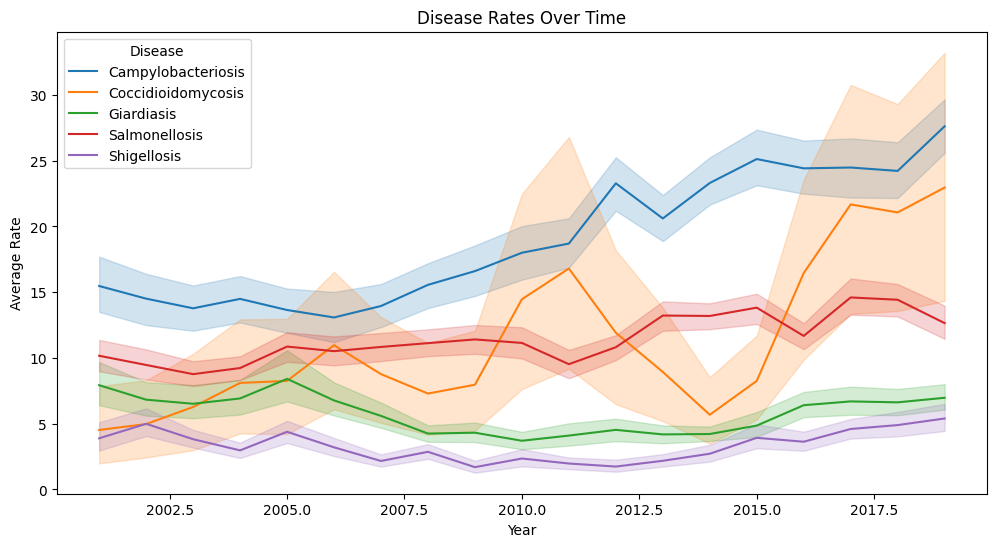

In [23]:
# disease over time (top 5)

top5 = disease_totals.head(5).index

top5_df = diseases[diseases["Disease"].isin(top5)]

plt.figure(figsize=(12,6))

sns.lineplot(data=top5_df,x="Year",y="Rate",hue="Disease",estimator="mean")

plt.title("Disease Rates Over Time")
plt.ylabel("Average Rate")

plt.show()

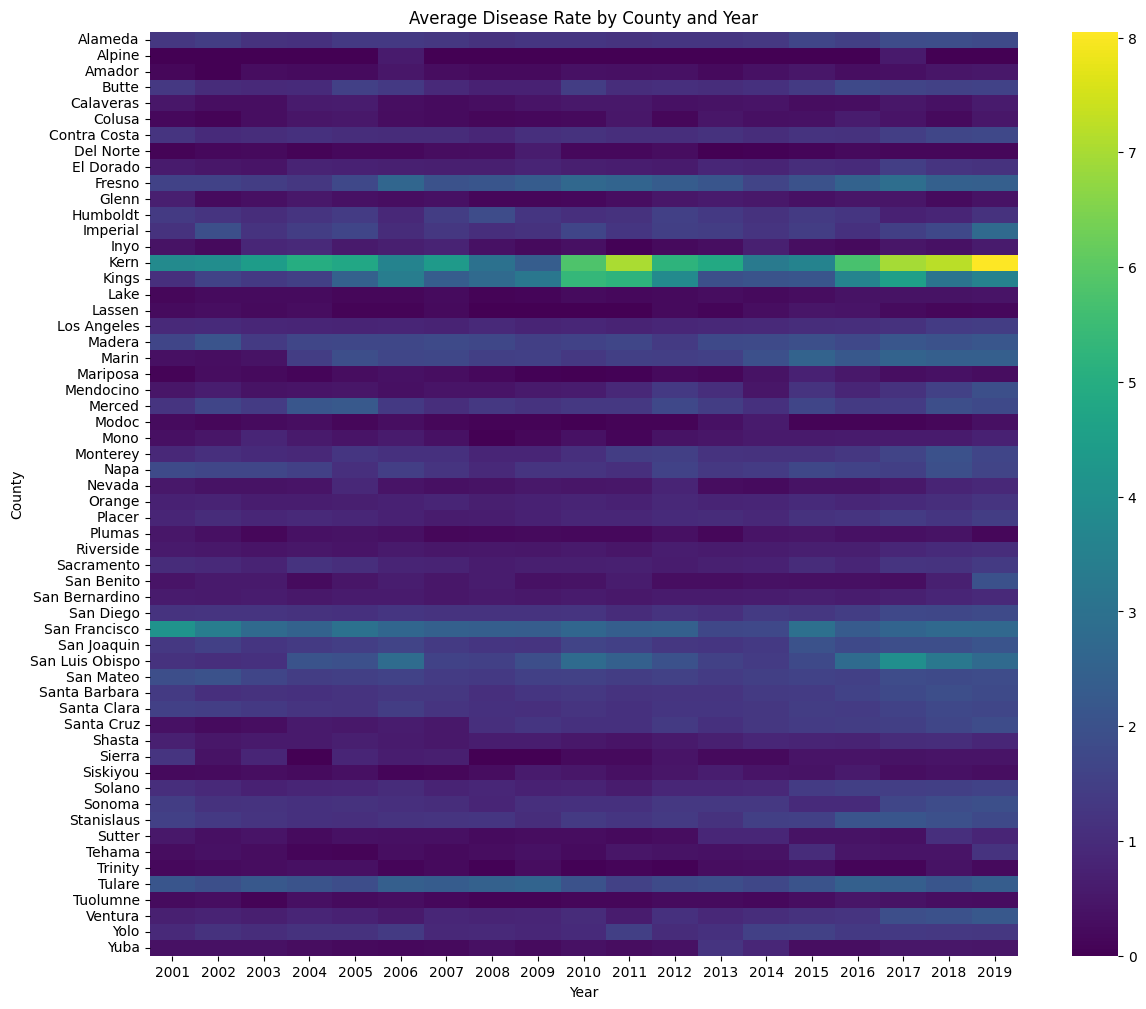

In [24]:
# country-year heatmap

county_year = (diseases.groupby(["County", "Year"])["Rate"].mean().reset_index())

heatmap_data = county_year.pivot(index="County", columns="Year", values="Rate")

plt.figure(figsize=(14,12))

sns.heatmap(heatmap_data,cmap="viridis")

plt.title("Average Disease Rate by County and Year")

plt.show()

## Normality Check (Shapiro-Wilk)

In [25]:
alpha = 0.05

sample_rates = (diseases["Rate"].dropna().sample(min(len(diseases), 200), random_state=42))

shapiro_stat, shapiro_pvalue = stats.shapiro(standardize(sample_rates))
print(f"Shapiro-Wilk: stat={shapiro_stat:.4f}, pvalue={shapiro_pvalue:.6f}")
decision(shapiro_pvalue, alpha)

Shapiro-Wilk: stat=0.2606, pvalue=0.000000
reject H0: pvalue=1.3630309446035853e-27 < 0.05


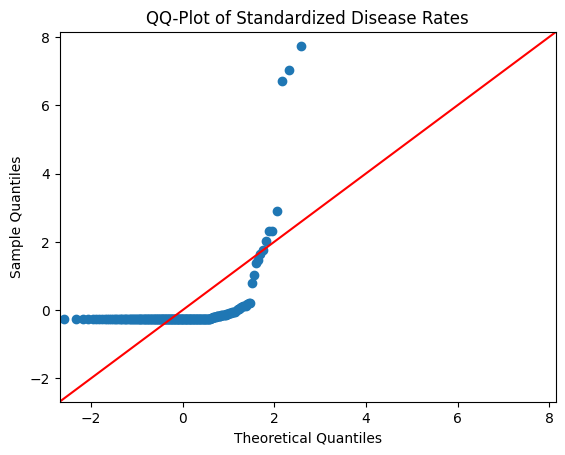

In [26]:
sm.qqplot(standardize(sample_rates), stats.norm, line='45')
plt.title("QQ-Plot of Standardized Disease Rates")
plt.show()

### Kruskal Wallis Test - Difference between each county

In [27]:
alpha = 0.05

county_groups = [group["Rate"].dropna().values for _, group in diseases.groupby("County")]

kruskal_stat, kruskal_pvalue = stats.kruskal(*county_groups)
print(f"Kruskal-Wallis: stat={kruskal_stat:.4f}, pvalue={kruskal_pvalue:.6e}")
decision(kruskal_pvalue, alpha)

Kruskal-Wallis: stat=20591.7770, pvalue=0.000000e+00
reject H0: pvalue=0.0 < 0.05


## Chi-Square Test — Differences between Sexes for each disease

In [28]:
alpha = 0.05

sex_disease = diseases[diseases["Sex"].isin(["Male", "Female"])].copy()
contingency = pd.crosstab(sex_disease["Sex"], sex_disease["Disease"], values=sex_disease["Cases"], aggfunc="sum").fillna(0)
# Remove disease columns with total = 0
contingency = contingency.loc[:, contingency.sum(axis=0) > 0]

print("Contingency table shape:", contingency.shape)
contingency.head()

Contingency table shape: (2, 50)


Disease,Amebiasis,Anaplasmosis,Babesiosis,"Botulism, Foodborne","Botulism, Other","Botulism, Wound",Brucellosis,Campylobacteriosis,Chikungunya Virus Infection,Cholera,...,Shigellosis,Spotted Fever Rickettsiosis,Streptococcal Infection (cases in food and dairy workers),Trichinosis,Tularemia,"Typhoid Fever, case",Typhus Fever,Vibrio Infection (non-Cholera),Yersiniosis,Zika Virus Infection
Sex,,,,,,,,,,,,,,,,,,,,,
Female,2039.0,24.0,20.0,25.0,4.0,98.0,248.0,57838.0,82.0,7.0,...,15190.0,53.0,140.0,18.0,17.0,700.0,472.0,1038.0,1103.0,462.0
Male,4604.0,23.0,34.0,31.0,4.0,338.0,260.0,68694.0,55.0,5.0,...,20602.0,76.0,176.0,56.0,26.0,709.0,599.0,1955.0,1156.0,198.0


In [29]:
T_stat, pvalue, dof, expected = stats.chi2_contingency(contingency.values)
print(f"Chi-square: T_stat={T_stat:.4f}, pvalue={pvalue:.6e}, dof={dof}")
decision(pvalue, alpha)

Chi-square: T_stat=7060.3133, pvalue=0.000000e+00, dof=49
reject H0: pvalue=0.0 < 0.05


In [30]:
# Chi-square test per top 10 disease individually
top_diseases = (diseases.groupby("Disease")["Cases"] .sum() .sort_values(ascending=False).head(10).index)
print("Chi-square test by disease (Male vs Female):\n")
for disease in top_diseases:
    sub = sex_disease[sex_disease["Disease"] == disease]
    ct = pd.crosstab(sub["Sex"], sub["County"], values=sub["Cases"], aggfunc="sum").fillna(0)

    # Remove counties with total = 0
    ct = ct.loc[:, ct.sum(axis=0) > 0]

    # Need at least 2 sexes and 2 counties
    if ct.shape[0] == 2 and ct.shape[1] >= 2:
        T_stat, pvalue, dof, expected = stats.chi2_contingency(ct.values)
        print(f"{disease}")
        print(f"Chi-square: T_stat={T_stat:.4f}, pvalue={pvalue:.6e}, dof={dof}")
        decision(pvalue, alpha)
        print()

Chi-square test by disease (Male vs Female):

Campylobacteriosis
Chi-square: T_stat=346.7728, pvalue=1.605122e-50, dof=40
reject H0: pvalue=1.605121546292428e-50 < 0.05

Salmonellosis
Chi-square: T_stat=131.8125, pvalue=7.492083e-13, dof=36
reject H0: pvalue=7.49208338932473e-13 < 0.05

Coccidioidomycosis
Chi-square: T_stat=1833.5003, pvalue=0.000000e+00, dof=34
reject H0: pvalue=0.0 < 0.05

Giardiasis
Chi-square: T_stat=894.7669, pvalue=3.339598e-165, dof=35
reject H0: pvalue=3.3395977993742044e-165 < 0.05

Shigellosis
Chi-square: T_stat=1023.1185, pvalue=4.083092e-192, dof=35
reject H0: pvalue=4.083091617229469e-192 < 0.05

Shiga toxin-producing E. coli (STEC) without HUS
Chi-square: T_stat=83.5648, pvalue=7.518862e-06, dof=35
reject H0: pvalue=7.518862006754954e-06 < 0.05

Cryptosporidiosis
Chi-square: T_stat=349.8115, pvalue=1.431447e-53, dof=35
reject H0: pvalue=1.4314467715435296e-53 < 0.05

Amebiasis
Chi-square: T_stat=450.8244, pvalue=1.069192e-73, dof=35
reject H0: pvalue=1.06

## Linear Regression — Rate Over Years

In [31]:
yearly = (diseases.groupby("Year")["Rate"].mean().reset_index())
yearly.columns = ["Year", "Rate"]

model_time = smf.ols("Rate ~ Year", data=yearly).fit()
print(model_time.summary())

                            OLS Regression Results                            
Dep. Variable:                   Rate   R-squared:                       0.632
Model:                            OLS   Adj. R-squared:                  0.611
Method:                 Least Squares   F-statistic:                     29.25
Date:                Fri, 22 May 2026   Prob (F-statistic):           4.71e-05
Time:                        06:09:48   Log-Likelihood:                 15.780
No. Observations:                  19   AIC:                            -27.56
Df Residuals:                      17   BIC:                            -25.67
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -49.7294      9.386     -5.298      0.0

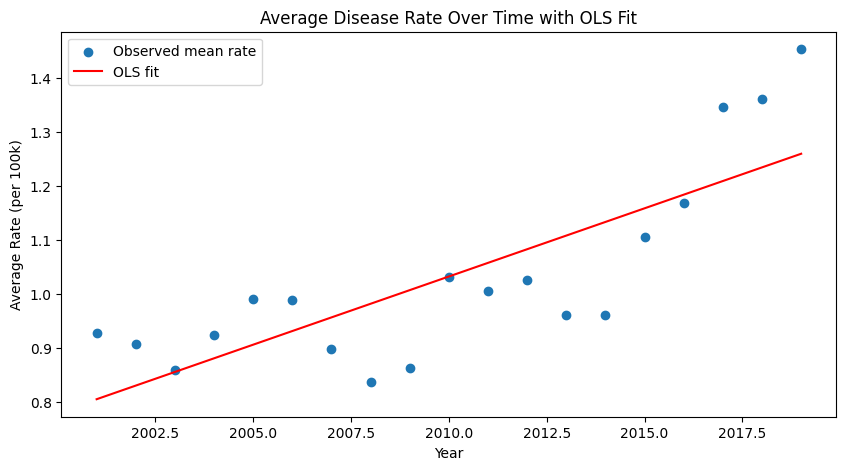

In [32]:
plt.figure(figsize=(10, 5))
plt.scatter(yearly["Year"], yearly["Rate"], label="Observed mean rate")
plt.plot(yearly["Year"], model_time.fittedvalues, color="red", label="OLS fit")
plt.title("Average Disease Rate Over Time with OLS Fit")
plt.xlabel("Year")
plt.ylabel("Average Rate (per 100k)")
plt.legend()
plt.show()

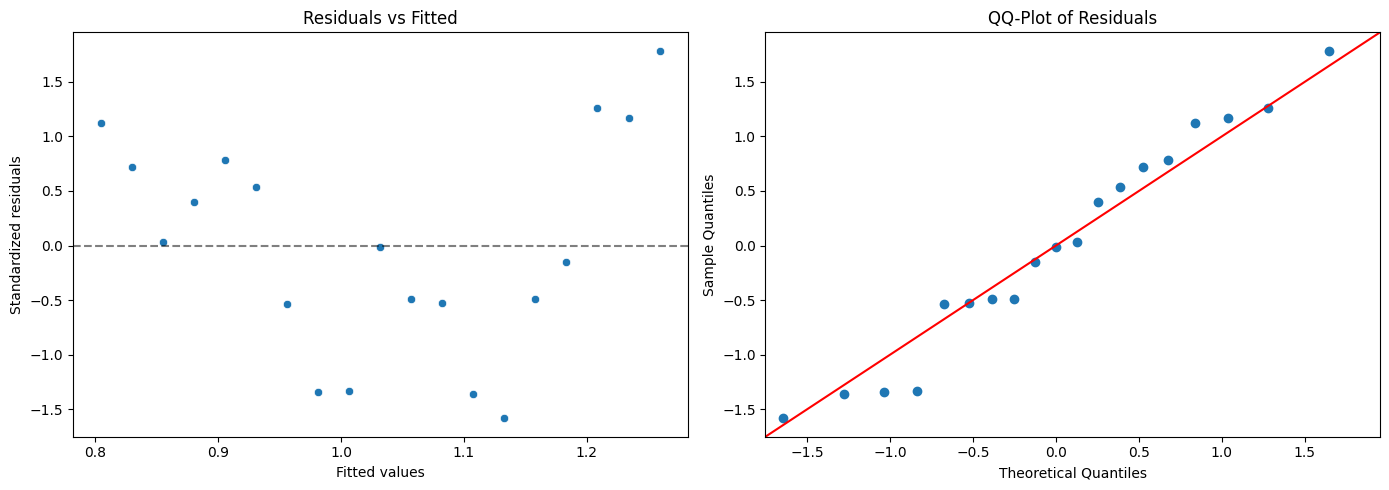

Shapiro test on residuals:
fail to reject H0: pvalue=0.4911427010065476 >= 0.05


In [33]:
residuals = model_time.resid
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=model_time.fittedvalues, y=standardize(residuals), ax=axs[0])
axs[0].axhline(0, color='black', linestyle='--', alpha=0.5)
axs[0].set_xlabel("Fitted values")
axs[0].set_ylabel("Standardized residuals")
axs[0].set_title("Residuals vs Fitted")

sm.qqplot(standardize(residuals), stats.norm, line='45', ax=axs[1])
axs[1].set_title("QQ-Plot of Residuals")

plt.tight_layout()
plt.show()

shapiro_resid = stats.shapiro(standardize(residuals))
print("Shapiro test on residuals:")
decision(shapiro_resid.pvalue, alpha=0.05)

## Multivariate Regression — Rate ~ Year + Sex + County

In [34]:
mv_df = diseases[diseases["Sex"].isin(["Male", "Female"])].copy()

mv_model = smf.ols("Rate ~ Year + C(Sex)", data=mv_df).fit()
print(mv_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   Rate   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     42.81
Date:                Fri, 22 May 2026   Prob (F-statistic):           2.61e-19
Time:                        06:09:56   Log-Likelihood:            -3.3919e+05
No. Observations:              103644   AIC:                         6.784e+05
Df Residuals:                  103641   BIC:                         6.784e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        -51.9226      7.267     -7.

In [35]:
#Does sex improve the Year-only model?
small_model = smf.ols("Rate ~ Year", data=mv_df).fit()
big_model = smf.ols("Rate ~ Year + C(Sex)", data=mv_df).fit()

anova_table = sm.stats.anova_lm(small_model, big_model)
print(anova_table)
decision(anova_table["Pr(>F)"].values[1], alpha=0.05)

   df_resid           ssr  df_diff      ss_diff          F        Pr(>F)
0  103642.0  4.224777e+06      0.0          NaN        NaN           NaN
1  103641.0  4.223435e+06      1.0  1342.451721  32.943101  9.515952e-09
reject H0: pvalue=9.515951603985057e-09 < 0.05


In [36]:
# Interaction model: Year:Sex for top 5 counties
top5counties = (diseases.groupby("County")["Rate"].mean().sort_values(ascending=False).head(5).index.tolist())

mv_county_df = mv_df[mv_df["County"].isin(top5counties)].copy()

model_interaction = smf.ols("Rate ~ Year + C(Sex) + C(County) + Year:C(Sex)",data=mv_county_df).fit()
print(model_interaction.summary().tables[1])

                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                     -129.8352     96.263     -1.349      0.177    -318.531      58.861
C(Sex)[T.Male]                 -32.6250    136.135     -0.240      0.811    -299.479     234.229
C(County)[T.Kern]                2.7954      0.588      4.756      0.000       1.643       3.948
C(County)[T.Kings]               0.7422      0.588      1.263      0.207      -0.410       1.894
C(County)[T.San Francisco]       0.4125      0.588      0.702      0.483      -0.740       1.565
C(County)[T.San Luis Obispo]    -0.0103      0.588     -0.018      0.986      -1.163       1.142
Year                             0.0653      0.048      1.364      0.173      -0.029       0.159
Year:C(Sex)[T.Male]              0.0169      0.068      0.250      0.803      -0.116       0.150
